In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import pandas as pd
import yfinance as yf
import time
from helpers import filter_daily_volume, drop_nan_days, get_all_us_tickers, get_data, filter_tickers
import numpy as np
import matplotlib.pyplot as plt
from TradingSim import TradingSim

In [3]:
tmp = pd.read_parquet("AllUSData-20100101-20260303.parquet")

In [4]:
full_df = tmp.copy()
qqq_spy = yf.download(["QQQ", "SPY"], start="2010-01-01", end="2026-03-03")
full_df = pd.concat([full_df, qqq_spy], axis=1)

C:\Users\sasso\AppData\Local\Temp\ipykernel_18316\3354087779.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  qqq_spy = yf.download(["QQQ", "SPY"], start="2010-01-01", end="2026-03-03")
[*********************100%***********************]  2 of 2 completed


In [5]:
def get_steady(df, start):
	end = start + pd.DateOffset(years=1)
	df = df[(df.index >= start) & (df.index <= end)]
	
	# df = full_df[full_df.index.year == year]

	rolling_data = df["Close"].ffill().pct_change(fill_method=None).rolling(window=30).mean() * 100
	rolling_data.columns = pd.MultiIndex.from_product([["rollingChange"], rolling_data.columns])
	df = df.join(rolling_data)

	df = filter_daily_volume(df, 2000000, True)
	df = drop_nan_days(df, "Close", 2)

	stats_df = pd.DataFrame(index=df.columns.get_level_values(1).unique().tolist())
	close = df["Close"]
	pct_change = ((close.iloc[-1] - close.iloc[0]) / close.iloc[0]) * 100
	daily_returns = close.pct_change()
	volatility = daily_returns.std() * np.sqrt(252) * 100 
	steady_score = pct_change / volatility

	stats_df["TotalReturn %"] = pct_change
	stats_df["Volatility %"] = volatility
	stats_df["SteadyScore"] = steady_score
	stats_df["PositiveDays %"] = (daily_returns > 0).mean() * 100

	# max drawdown - Distance between lowest and peak
	rolling_max = close.cummax()
	daily_drawdown = (close - rolling_max) / rolling_max  # Distance from peak
	stats_df["MaxDrawdown %"] = daily_drawdown.min() * 100  # % distance from worst drop

	sma_50 = df["Close"].rolling(window=50).mean().iloc[-1]
	stats_df["DistFromSMA50 %"] = ((close.iloc[-1] / sma_50) - 1) * 100

	median_vol_30d = df["Volume"].rolling(window=30).median().iloc[-1]
	stats_df["VolumeSurgeRatio"] = df["Volume"].iloc[-1] / median_vol_30d

	daily_range = df["High"] - df["Low"]
	atr_14 = daily_range.rolling(window=14).mean().iloc[-1]
	stats_df["ATR %"] = (atr_14 / df["Close"].iloc[-1]) * 100
	score_df = stats_df.copy()
	score_df["TotalReturn"] = score_df["TotalReturn %"].rank(pct=True) * 100
	score_df["Volatility %"] = score_df["Volatility %"].rank(pct=True, ascending=False) * 100
	score_df["SteadyScore"] = score_df["SteadyScore"].rank(pct=True) * 100
	score_df["PositiveDays"] = score_df["PositiveDays %"].rank(pct=True) * 100
	score_df["MaxDrawdown %"] = score_df["MaxDrawdown %"].rank(pct=True) * 100
	score_df["DistFromSMA50 %"] = score_df["DistFromSMA50 %"].rank(pct=True) * 100
	score_df["VolumeSurgeRatio"] = score_df["VolumeSurgeRatio"].rank(pct=True) * 100
	score_df["ATR %"] = score_df["ATR %"].rank(pct=True, ascending=False) * 100

	score_df.rename(columns={"Volatility %": "Volatility", "MaxDrawdown %": "MaxDrawdown", "DistFromSMA50 %": "DistFromSMA50", "ATR %": "ATR"}, inplace=True)
	
	# filter_column(score_df, "TotalReturn %", 40)

	weights = {
		"TotalReturn": 4,
		"Volatility": 3,
		"SteadyScore": 9,
		"PositiveDays": 3,
		"MaxDrawdown": 8,
		"DistFromSMA50": 2,
		"VolumeSurgeRatio": 1,
		"ATR": 5
	}
	score_df["FinalScore"] = (
		(score_df["TotalReturn"] * weights["TotalReturn"]) +
		(score_df["Volatility"] * weights["Volatility"]) +
		(score_df["SteadyScore"] * weights["SteadyScore"]) +
		(score_df["PositiveDays"] * weights["PositiveDays"]) +
		(score_df["MaxDrawdown"] * weights["MaxDrawdown"]) +
		(score_df["DistFromSMA50"] * weights["DistFromSMA50"]) +
		(score_df["VolumeSurgeRatio"] * weights["VolumeSurgeRatio"]) +
		(score_df["ATR"] * weights["ATR"])
	)
	score_df["FinalScore"] = score_df["FinalScore"].rank(pct=True) * 100
	score_df.dropna(subset=["FinalScore"], inplace=True)
	score_df["Rank"] = score_df["FinalScore"].rank(ascending=False, method="min").astype(int)
	return score_df

def get_returns(df, entry, tickers, start=None, end=None):
	if start and end:
		df = df[(df.index >= start) & (df.index <= end)]
	sim = TradingSim(df)
	return sim.optimizer_exit_after(entry, tickers)

def get_plot(returns, avg_ret=None, plot_size=80):
	tickers = returns.columns
	line_styles = ['--' if ticker in ['QQQ', 'SPY'] else '-' for ticker in tickers]
	returns[returns.index < plot_size].plot(figsize=(12, 6), style=line_styles)
	if avg_ret:
		plt.annotate(f"{round(avg_ret[1], 2)}%", xy=(avg_ret[0] + 0.5, avg_ret[1] + 0.5), color='indigo', fontweight="bold")
		plt.axvline(x=avg_ret[0], linestyle=":", color="indigo")
		plt.axhline(y=avg_ret[1], linestyle=":", color="indigo")
	plt.grid(True, linestyle="--", alpha=0.7)


In [30]:
# exit_after = 40
year = 2011
look_after = 120  # After that algorithm is shit and we won't listen to it
sell_not_before = 10
# counter = {}
counter = pd.Series(0, index=range(look_after + 2))
i = 0
# for year in range(2010, 2025)
for year in range(2010, 2025):
    for month in range(1, 13):
        start = pd.to_datetime(f"{year}-01-01") + pd.DateOffset(month=month)
        print(f"\r{start}-----{i} / {12*15}", end="")
        i += 1
        # score_df = get_steady(full_df, start).sort_values("FinalScore", ascending=False)
        score_df = get_steady(full_df, start)
        entry = start + pd.DateOffset(years=1)
        # top_tickers = score_df.head(3)
        top_tickers = score_df[(score_df["Volatility"] > 70) & (score_df["TotalReturn %"] > 100)].sort_values("FinalScore", ascending=False).head(3)
        returns, returns_mean = get_returns(full_df, entry, top_tickers.index.to_list(), entry, entry + pd.DateOffset(days=look_after))
        # returns, returns_mean = get_returns(full_df, entry, top_tickers.index.to_list() + ["QQQ", "SPY"])
        best_exists = returns_mean.loc[sell_not_before + 1 : look_after].sort_values(ascending=False)
        best_exit_idx = best_exists.index[0]
        best_exit_val =  best_exists.values[0]
        # if str(best_exit_idx) not in counter:
        #     counter.loc[str(best_exit_idx)] = 0
        # if str(best_exit_idx + 1) not in counter:
        #     counter.loc[str(best_exit_idx + 1)] = 0
        # if str(best_exit_idx - 1) not in counter:
        #     counter.loc[str(best_exit_idx - 1)] = 0
        # counter.loc[str(best_exit_idx)] += 2
        # counter.loc[str(best_exit_idx + 1)] += 1
        # counter.loc[str(best_exit_idx - 1)] += 1
        counter[best_exit_idx] += 2
        counter[best_exit_idx + 1] += 1
        counter[best_exit_idx - 1] += 1
    # print(best_exit_idx)
    # print(best_exit_val)
counter = counter.to_frame(name='count')
print(counter)
    # avg_ret = returns_mean.iloc[best_exit]
    # returns_mean.head(80).plot()
    # get_plot(returns, (best_exit_idx, best_exit_val))

2023-11-01 00:00:00-----166 / 180

c:\Users\sasso\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


2024-12-01 00:00:00-----179 / 180

C:\Users\sasso\AppData\Local\Temp\ipykernel_18448\2440647368.py:17: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = close.pct_change()


     count
0        0
1        0
2        0
3        0
4        0
..     ...
117      0
118      0
119      0
120      0
121      0

[122 rows x 1 columns]


In [6]:
sell_after = 80
i = 0
avg_ret = []
idxs_avg_ret = []
all_scores = {}
# for year in range(2010, 2025)
for year in range(2010, 2025):
    for month in range(1, 13):
        start = pd.to_datetime(f"{year}-01-01") + pd.DateOffset(month=month)
        i += 1
        print(f"\r{start}-----{i} / {12*15}", end="")
        score_df = get_steady(full_df, start)
        all_scores[start] = score_df.copy()
        continue
        top_tickers = score_df[(score_df["Volatility"] > 80) & (score_df["TotalReturn %"] > 50)].sort_values("FinalScore", ascending=False).head(3)
        entry = start + pd.DateOffset(years=1)
        returns, returns_mean = get_returns(full_df, entry, top_tickers.index.to_list() + ["QQQ", "SPY"], entry, entry + pd.DateOffset(days=sell_after))
        idxs_ret = returns[["QQQ", "SPY"]].iloc[-1].mean()
        mean_ret = returns_mean.iloc[-1]
        if pd.isna(mean_ret):
            continue
        avg_ret.append(mean_ret)
        idxs_avg_ret.append(idxs_ret)
        print(entry)
        print(f"Index mean return after {sell_after} days: {round(sum(idxs_avg_ret)/len(idxs_avg_ret), 2)}%")
        print(f"Tickers mean return after {sell_after} days: {round(sum(avg_ret)/len(avg_ret), 2)}%")
        print("-------------------------")

    # avg_ret = returns_mean.iloc[best_exit]
    # returns_mean.head(80).plot()
    # get_plot(returns, (best_exit_idx, best_exit_val))

2023-11-01 00:00:00-----167 / 180

c:\Users\sasso\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


2024-12-01 00:00:00-----180 / 180

C:\Users\sasso\AppData\Local\Temp\ipykernel_18316\2350144714.py:17: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = close.pct_change()


In [7]:
all_returns = {}
all_mean_returns = {}
for start in all_scores:
    score_df = all_scores[start]
    entry = start + pd.DateOffset(years=1)
    returns = get_returns(full_df, entry, score_df.index.to_list())
    all_returns[start] = returns[0]
    all_mean_returns[start] = returns[1]
    

In [8]:

vars_returns = pd.DataFrame(columns=["Sell after", "Volatility", "TotalReturn %", "Indexes Return", "Tickers Return"])
i = 0 
for sell_after in range(20, 70, 5):
    for vol in range(75, 100, 5):
        for total_ret in range(40, 140, 10):
            avg_rets = []
            idxs_avg_rets = []
            print(f"\r{i}", end="")
            i += 1
            for start in all_scores:
                score_df = all_scores[start]
                top_tickers = score_df[(score_df["Volatility"] > vol) & (score_df["TotalReturn %"] > total_ret)].sort_values("FinalScore", ascending=False).head(3)
                # entry = start + pd.DateOffset(years=1)
                returns = all_returns[start][top_tickers.index.to_list() + ["QQQ", "SPY"]][: sell_after]
                # returns_mean = all_mean_returns[start]
                # returns, returns_mean = get_returns(full_df, entry, top_tickers.index.to_list() + ["QQQ", "SPY"], entry, entry + pd.DateOffset(days=sell_after))
                idxs_ret = returns[["QQQ", "SPY"]].iloc[-1].mean()
                mean_ret = returns.drop(columns=["QQQ", "SPY"]).mean(axis=1).iloc[-1]
                if pd.isna(mean_ret):
                    continue
                avg_rets.append(mean_ret)
                idxs_avg_rets.append(idxs_ret)
            idxs_avg_ret = sum(idxs_avg_rets) / len(idxs_avg_rets)
            avg_ret = sum(avg_rets) / len(avg_rets)
            vars_returns.loc[len(vars_returns)] = [sell_after, vol, total_ret, idxs_avg_ret, avg_ret]
# print(f"Index mean return after {sell_after} days: {round(sum(idxs_avg_ret)/len(idxs_avg_ret), 2)}%")
# print(f"Tickers mean return after {sell_after} days: {round(sum(avg_ret)/len(avg_ret), 2)}%")


499

In [9]:
# vars_returns.sort_values("Tickers Return", ascending=False)
# vars_returns
# vars_returns[vars_returns["Indexes Return"] < vars_returns["Tickers Return"]].sort_values("Sell after", ascending=False).head(20)
vars_returns["ret per day"] = vars_returns["Tickers Return"] / vars_returns["Sell after"]
vars_returns["diff"] = vars_returns["Tickers Return"] - vars_returns["Indexes Return"]
vars_returns.sort_values("ret per day", ascending=False).head(40)

,Sell after,Volatility,TotalReturn %,Indexes Return,Tickers Return,ret per day,diff
48,20.0,95.0,120.0,2.873068,19.912900,0.995645,17.039832
49,20.0,95.0,130.0,2.873068,19.912900,0.995645,17.039832
98,25.0,95.0,120.0,4.439136,24.404593,0.976184,19.965458
99,25.0,95.0,130.0,4.439136,24.404593,0.976184,19.965458
148,30.0,95.0,120.0,5.848459,25.264839,0.842161,19.416380
149,30.0,95.0,130.0,5.848459,25.264839,0.842161,19.416380
198,35.0,95.0,120.0,5.543621,24.440863,0.698310,18.897241
199,35.0,95.0,130.0,5.543621,24.440863,0.698310,18.897241
348,50.0,95.0,120.0,7.163210,30.999934,0.619999,23.836724
349,50.0,95.0,130.0,7.163210,30.999934,0.619999,23.836724


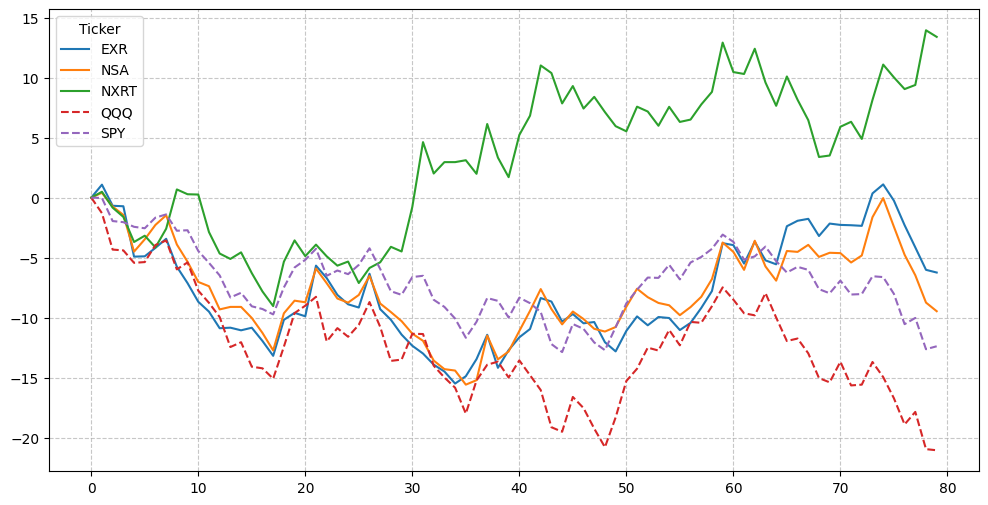

In [11]:
# exit_after = 40
year = 2021
look_after = 120  # After that algorithm is shit and we won't listen to it
sell_not_before = 10
# for year in range(2010, 2025)
start = pd.to_datetime(f"{year}-01-01")
score_df = get_steady(full_df, start).sort_values("FinalScore", ascending=False)
entry = start + pd.DateOffset(years=1)
# top_tickers = score_df.head(3)
top_tickers = score_df[(score_df["Volatility"] > 70) & (score_df["TotalReturn %"] > 100)].sort_values("FinalScore", ascending=False).head(3)
# returns, returns_mean = get_returns(full_df, entry, top_tickers.index.to_list(), entry, entry + pd.DateOffset(days=look_after))
returns, returns_mean = get_returns(full_df, entry, top_tickers.index.to_list() + ["QQQ", "SPY"])
get_plot(returns)

,count
80,31
79,31
78,27
81,26
77,22
...,...
117,0
118,0
119,0
120,0


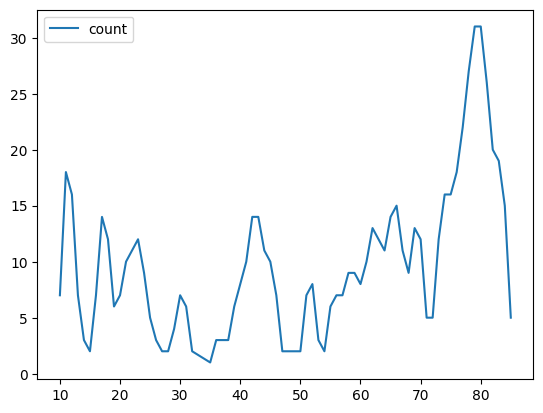

In [43]:
# dict(sorted(counter.items(), key=lambda item: item[1], reverse=True))
# counter.loc["ta"] = 2
counter[counter["count"] > 0].plot()
counter.sort_values(by='count', ascending=False)